<a href="https://colab.research.google.com/github/Visweash1234/Applied-Data-Science-1/blob/main/ADS1_Tutorial_4_1_Basic_Statistics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.power import TTestIndPower
from statsmodels.stats.multitest import multipletests

sns.set_theme(style="whitegrid", context="notebook")
rng = np.random.default_rng(42)   # one generator for every simulation below

In [2]:
# Dataset 1: restaurant tips (ships with seaborn)
tips = sns.load_dataset("tips")

In [3]:
# Dataset 2: supplier lead times in days (simulated, reproducible)
def make_lead_times(seed=55):
    r = np.random.default_rng(seed)
    # 2,000 historical orders from Supplier A
    history = pd.DataFrame({"lead_time_days": r.lognormal(np.log(10), 0.25, 2000).round(1)})
    # 60 recent orders from each supplier
    a = r.lognormal(np.log(10), 0.25, 60)
    fast = r.lognormal(np.log(8.5), 0.20, 60)
    slow = r.lognormal(np.log(15), 0.25, 60)
    b = np.where(r.random(60) < 0.85, fast, slow)   # B is usually fast, sometimes very slow
    orders = pd.DataFrame({"supplier": ["A"] * 60 + ["B"] * 60,
                           "lead_time_days": np.r_[a, b].round(1)})
    return history, orders

history, orders = make_lead_times()
print("tips:", tips.shape, "| history:", history.shape, "| orders:", orders.shape)
orders.head()

tips: (244, 7) | history: (2000, 1) | orders: (120, 2)


,supplier,lead_time_days
0,A,11.3
1,A,7.2
2,A,15.3
3,A,16.2
4,A,14.3


In [6]:
x = [2, 4, 6]
print("np.std(x)            ", np.std(x))             # ddof=0, ÷n
print("np.std(x, ddof=1)    ", np.std(x, ddof=1))     # ÷(n-1)
print("pd.Series(x).std()   ", pd.Series(x).std())    # pandas default ddof=1

np.std(x)             1.632993161855452
np.std(x, ddof=1)     2.0
pd.Series(x).std()    2.0


In [7]:
x = pd.Series([2, 4, 6, 8, 200])
q1, q3 = x.quantile([0.25, 0.75])
iqr = q3 - q1
summary = pd.Series({
    "mean": x.mean(), "median": x.median(),
    "std (ddof=1)": x.std(), "IQR": iqr,
    "MAD": stats.median_abs_deviation(x),
})
print(summary.round(2))

z = (x - x.mean()) / x.std()
print("\nz-score of 200:", round(z.iloc[-1], 2), "→ flagged by |z| > 3?", abs(z.iloc[-1]) > 3)
print("IQR upper fence:", q3 + 1.5 * iqr, "→ 200 flagged?", 200 > q3 + 1.5 * iqr)

mean            44.00
median           6.00
std (ddof=1)    87.24
IQR              4.00
MAD              2.00
dtype: float64

z-score of 200: 1.79 → flagged by |z| > 3? False
IQR upper fence: 14.0 → 200 flagged? True


In [8]:
normal = pd.Series(rng.normal(size=100_000))
heavy  = pd.Series(rng.laplace(size=100_000))
print("normal: skew %.2f  excess kurt %.2f" % (normal.skew(), normal.kurt()))
print("Laplace: skew %.2f  excess kurt %.2f  (theory: 3, heavier tails)" % (heavy.skew(), heavy.kurt()))

normal: skew 0.01  excess kurt 0.02
Laplace: skew -0.01  excess kurt 3.06  (theory: 3, heavier tails)


### Practice 1: Summarize *tips* and hunt for outliers
Let's start by looking at the summary statistics, skewness, and kurtosis of `total_bill` and `tip`.

In [9]:
# 1. Run describe() on total_bill and tip
summary_stats = tips[['total_bill', 'tip']].describe()
display(summary_stats)

# Compare mean vs median (50%)
print("total_bill mean - median:", round(tips['total_bill'].mean() - tips['total_bill'].median(), 2))
print("tip mean - median:", round(tips['tip'].mean() - tips['tip'].median(), 2))

,total_bill,tip
count,244.000000,244.000000
mean,19.785943,2.998279
std,8.902412,1.383638
min,3.070000,1.000000
25%,13.347500,2.000000
50%,17.795000,2.900000
75%,24.127500,3.562500
max,50.810000,10.000000


total_bill mean - median: 1.99
tip mean - median: 0.1


Now we'll calculate numerical metrics for skewness and excess kurtosis to determine if either variable has a heavy tail.

In [10]:
# 2. Compute skew() and kurt()
for col in ['total_bill', 'tip']:
    print(f"{col:10} | Skewness: {tips[col].skew():.2f} | Excess Kurtosis: {tips[col].kurt():.2f}")

total_bill | Skewness: 1.13 | Excess Kurtosis: 1.22
tip        | Skewness: 1.47 | Excess Kurtosis: 3.65


Let's identify outliers under both the Z-score rule ($|z| > 3$) and the IQR rule, and see how they compare.

In [11]:
# 3. Flag outliers with the z-score rule and the IQR rule
outliers_df = pd.DataFrame(index=tips.index)

for col in ['total_bill', 'tip']:
    # Z-score rule
    z_scores = (tips[col] - tips[col].mean()) / tips[col].std()
    outliers_df[f'{col}_z_flag'] = np.abs(z_scores) > 3

    # IQR rule
    q1 = tips[col].quantile(0.25)
    q3 = tips[col].quantile(0.75)
    iqr = q3 - q1
    outliers_df[f'{col}_iqr_flag'] = (tips[col] < (q1 - 1.5 * iqr)) | (tips[col] > (q3 + 1.5 * iqr))

# Summary of flags
print("Total bill outliers (Z-score):", outliers_df['total_bill_z_flag'].sum())
print("Total bill outliers (IQR):    ", outliers_df['total_bill_iqr_flag'].sum())
print("\nTip outliers (Z-score):       ", outliers_df['tip_z_flag'].sum())
print("Tip outliers (IQR):           ", outliers_df['tip_iqr_flag'].sum())

# Intersection / Agreement
print("\nAgreement on total_bill outliers:", (outliers_df['total_bill_z_flag'] & outliers_df['total_bill_iqr_flag']).sum())
print("Agreement on tip outliers:      ", (outliers_df['tip_z_flag'] & outliers_df['tip_iqr_flag']).sum())

Total bill outliers (Z-score): 4
Total bill outliers (IQR):     9

Tip outliers (Z-score):        3
Tip outliers (IQR):            9

Agreement on total_bill outliers: 4
Agreement on tip outliers:       3


Finally, we compare the daily distribution of `total_bill` using a Box Plot, Violin Plot, and ECDF (Empirical Cumulative Distribution Function) plot.

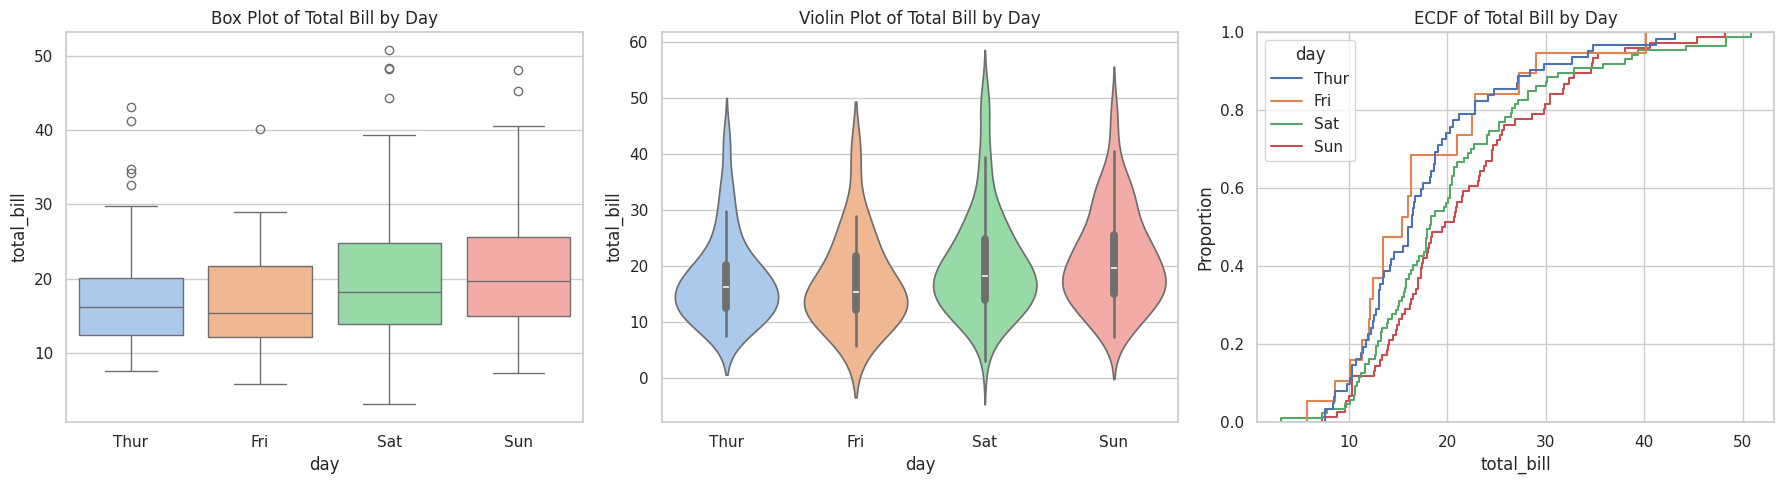

In [12]:
# 4. Plot total_bill by day as a box plot, a violin plot, and an ECDF
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Box Plot
sns.boxplot(data=tips, x='day', y='total_bill', ax=axes[0], palette='pastel', hue='day', legend=False)
axes[0].set_title('Box Plot of Total Bill by Day')

# Violin Plot
sns.violinplot(data=tips, x='day', y='total_bill', ax=axes[1], palette='pastel', hue='day', legend=False)
axes[1].set_title('Violin Plot of Total Bill by Day')

# ECDF Plot
sns.ecdfplot(data=tips, x='total_bill', hue='day', ax=axes[2])
axes[2].set_title('ECDF of Total Bill by Day')

plt.tight_layout()
plt.show()

In [13]:
print("Poisson(3)  P(X=2)        =", round(stats.poisson(3).pmf(2), 3))
print("Normal(0,.25) pdf at 0    =", round(stats.norm(0, 0.25).pdf(0), 3), " ← a density can exceed 1")
print("Normal CDF at 1.96        =", round(stats.norm().cdf(1.96), 3))
print("Normal PPF at 0.975       =", round(stats.norm().ppf(0.975), 3))
print("Normal SF  at 1.96 (1-cdf)=", round(stats.norm().sf(1.96), 3))

Poisson(3)  P(X=2)        = 0.224
Normal(0,.25) pdf at 0    = 1.596  ← a density can exceed 1
Normal CDF at 1.96        = 0.975
Normal PPF at 0.975       = 1.96
Normal SF  at 1.96 (1-cdf)= 0.025


mean, var, skew, excess kurt: [0.5, 0.25, 2.0, 6.0]


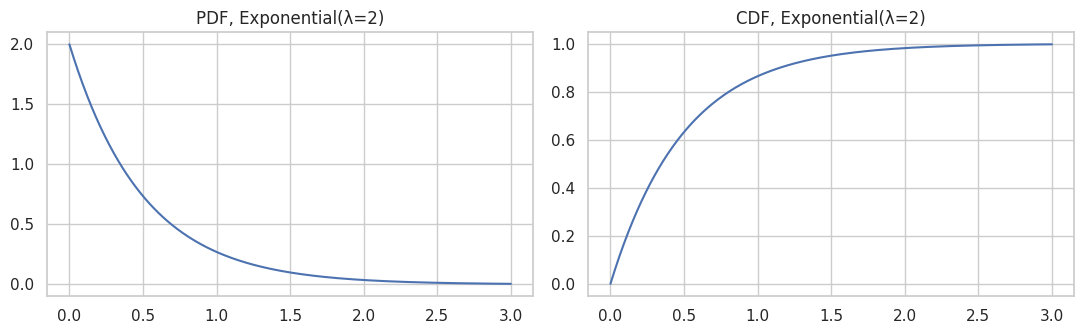

In [14]:
d = stats.expon(scale=1/2)
print("mean, var, skew, excess kurt:", [round(float(v), 3) for v in d.stats(moments="mvsk")])

grid = np.linspace(0, 3, 300)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].plot(grid, d.pdf(grid)); axes[0].set_title("PDF, Exponential(λ=2)")
axes[1].plot(grid, d.cdf(grid)); axes[1].set_title("CDF, Exponential(λ=2)")
plt.tight_layout()

### Practice 2: Fit and check a distribution for supplier lead times

<>:18: SyntaxWarning: invalid escape sequence '\m'
<>:18: SyntaxWarning: invalid escape sequence '\s'
<>:18: SyntaxWarning: invalid escape sequence '\m'
<>:18: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_1205/2951920608.py:18: SyntaxWarning: invalid escape sequence '\m'
  plt.plot(x_grid, pdf_norm, label=f"Fitted Normal (\mu={mu_norm:.2f}, \sigma={std_norm:.2f})", color="blue", lw=2)
/tmp/ipykernel_1205/2951920608.py:18: SyntaxWarning: invalid escape sequence '\s'
  plt.plot(x_grid, pdf_norm, label=f"Fitted Normal (\mu={mu_norm:.2f}, \sigma={std_norm:.2f})", color="blue", lw=2)


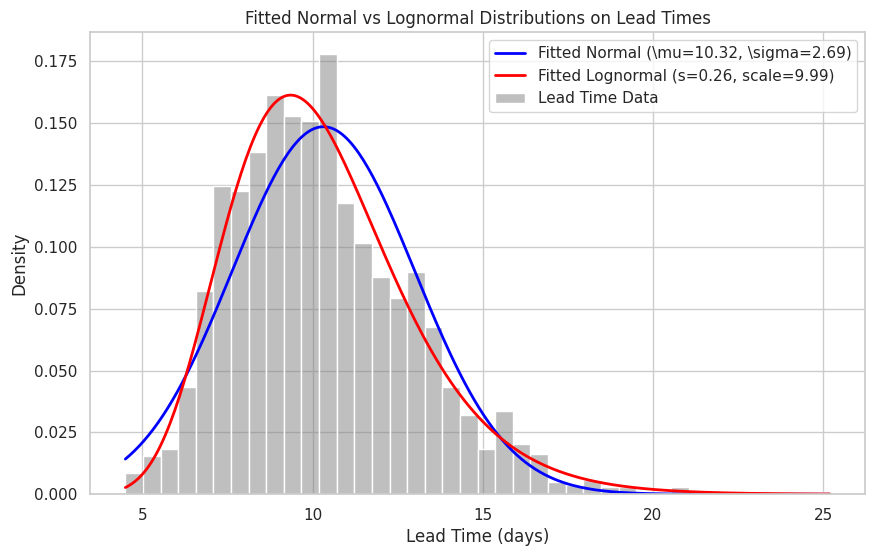

In [15]:
# 1. Overlay fitted normal and lognormal PDFs on a histogram of history.lead_time_days
data = history['lead_time_days']
mu_norm, std_norm = stats.norm.fit(data)
s_logn, loc_logn, scale_logn = stats.lognorm.fit(data, floc=0)

# Plot histogram
plt.figure(figsize=(10, 6))
sns.histplot(data, stat="density", bins=40, alpha=0.5, label="Lead Time Data", color="gray")

# Generate a grid of values for plotting the curves
x_grid = np.linspace(data.min(), data.max(), 300)

# Calculate PDFs
pdf_norm = stats.norm.pdf(x_grid, mu_norm, std_norm)
pdf_logn = stats.lognorm.pdf(x_grid, s_logn, loc_logn, scale_logn)

# Plot PDF curves
plt.plot(x_grid, pdf_norm, label=f"Fitted Normal (\mu={mu_norm:.2f}, \sigma={std_norm:.2f})", color="blue", lw=2)
plt.plot(x_grid, pdf_logn, label=f"Fitted Lognormal (s={s_logn:.2f}, scale={scale_logn:.2f})", color="red", lw=2)

plt.title("Fitted Normal vs Lognormal Distributions on Lead Times")
plt.xlabel("Lead Time (days)")
plt.ylabel("Density")
plt.legend()
plt.show()

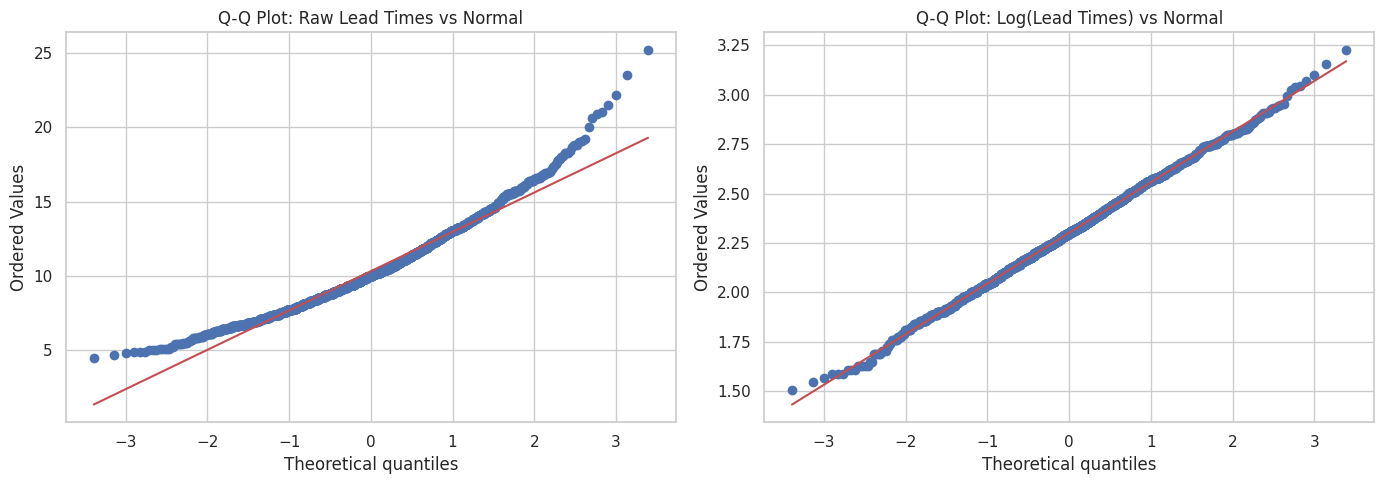

In [16]:
# 2. Q-Q plot of raw data against the normal, then of np.log(lead_time_days)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Q-Q plot: Raw Data vs Normal
stats.probplot(data, dist="norm", plot=axes[0])
axes[0].set_title("Q-Q Plot: Raw Lead Times vs Normal")

# Q-Q plot: Log-transformed Data vs Normal
stats.probplot(np.log(data), dist="norm", plot=axes[1])
axes[1].set_title("Q-Q Plot: Log(Lead Times) vs Normal")

plt.tight_layout()
plt.show()

In [17]:
# 3. Shapiro-Wilk test on 50 rows vs. all rows
sample_50 = data.sample(50, random_state=1)

stat_50, p_50 = stats.shapiro(sample_50)
stat_all, p_all = stats.shapiro(data)

print(f"Shapiro-Wilk (Sample size = 50):  Stat={stat_50:.4f}, p-value={p_50:.4f}")
print(f"Shapiro-Wilk (All {len(data)} rows): Stat={stat_all:.4f}, p-value={p_all:.4f}")

Shapiro-Wilk (Sample size = 50):  Stat=0.9777, p-value=0.4583
Shapiro-Wilk (All 2000 rows): Stat=0.9669, p-value=0.0000


In [18]:
# 4. With the lognormal fit: P(lead time > 14 days)? The 95th percentile?
# Using the fitted lognormal parameters (s_logn, loc_logn, scale_logn):
# P(X > 14) = 1 - CDF(14) = SF(14)
p_greater_14 = stats.lognorm.sf(14, s_logn, loc_logn, scale_logn)

# 95th percentile (using the percent point function / inverse CDF)
pct_95 = stats.lognorm.ppf(0.95, s_logn, loc_logn, scale_logn)

print(f"Probability(Lead Time > 14 days): {p_greater_14 * 100:.2f}%")
print(f"95th Percentile of Lead Time:    {pct_95:.2f} days")

Probability(Lead Time > 14 days): 9.35%
95th Percentile of Lead Time:    15.22 days


### Practice 3: See the CLT happen, then quantify uncertainty

In [19]:
# 1. Simulate 10,000 sample means from Exponential(1) for n = 1, 5, 30
num_simulations = 10000
sample_sizes = [1, 5, 30]

# True exponential(1) parameters: mean = 1, SD = 1, Skew = 2
for n in sample_sizes:
    # Draw samples of shape (num_simulations, n)
    samples = rng.exponential(scale=1.0, size=(num_simulations, n))
    sample_means = samples.mean(axis=1)

    obs_sd = np.std(sample_means, ddof=1)
    obs_skew = stats.skew(sample_means)

    exp_sd = 1.0 / np.sqrt(n)
    exp_skew = 2.0 / np.sqrt(n)

    print(f"n = {n:2d} | Obs SD: {obs_sd:.4f} (Exp: {exp_sd:.4f}) | Obs Skew: {obs_skew:.4f} (Exp: {exp_skew:.4f})")

n =  1 | Obs SD: 1.0272 (Exp: 1.0000) | Obs Skew: 2.0722 (Exp: 2.0000)
n =  5 | Obs SD: 0.4438 (Exp: 0.4472) | Obs Skew: 0.8350 (Exp: 0.8944)
n = 30 | Obs SD: 0.1823 (Exp: 0.1826) | Obs Skew: 0.3388 (Exp: 0.3651)


In [20]:
# 2. Build 100 t-intervals (n = 20) from a population with known mu = 50
true_mu = 50
population_std = 10
n_samples = 20
confidence_level = 0.95

miss_count = 0

for _ in range(100):
    # Draw a sample of size n=20
    sample = rng.normal(loc=true_mu, scale=population_std, size=n_samples)
    sample_mean = np.mean(sample)
    sample_sem = stats.sem(sample)

    # Calculate t-interval boundaries
    interval = stats.t.interval(confidence_level, df=n_samples-1, loc=sample_mean, scale=sample_sem)

    # Check if the true mean falls outside the interval
    if true_mu < interval[0] or true_mu > interval[1]:
        miss_count += 1

print(f"Out of 100 constructed 95% t-intervals, {miss_count} missed the true mean of {true_mu}.")
print(f"Observed coverage rate: {100 - miss_count}%")

Out of 100 constructed 95% t-intervals, 3 missed the true mean of 50.
Observed coverage rate: 97%


In [21]:
# 3. Bootstrap a 95% CI for Supplier A's median lead time vs t-interval for the mean
supplier_a_data = orders[orders['supplier'] == 'A']['lead_time_days'].values

# Bootstrap the median
bootstrap_medians = []
num_boot_samples = 10000
for _ in range(num_boot_samples):
    boot_sample = rng.choice(supplier_a_data, size=len(supplier_a_data), replace=True)
    bootstrap_medians.append(np.median(boot_sample))

# Percentile bootstrap confidence interval (2.5th to 97.5th percentile)
ci_median_boot = np.percentile(bootstrap_medians, [2.5, 97.5])

# t-interval for the mean
mean_a = np.mean(supplier_a_data)
sem_a = stats.sem(supplier_a_data)
ci_mean_t = stats.t.interval(0.95, df=len(supplier_a_data)-1, loc=mean_a, scale=sem_a)

print(f"Supplier A (n={len(supplier_a_data)}):")
print(f"Bootstrap 95% CI for the MEDIAN: [{ci_median_boot[0]:.2f}, {ci_median_boot[1]:.2f}] (Observed Sample Median: {np.median(supplier_a_data):.2f})")
print(f"Classical 95% t-interval for the MEAN: [{ci_mean_t[0]:.2f}, {ci_mean_t[1]:.2f}] (Observed Sample Mean: {mean_a:.2f})")

Supplier A (n=60):
Bootstrap 95% CI for the MEDIAN: [9.50, 11.10] (Observed Sample Median: 10.30)
Classical 95% t-interval for the MEAN: [9.62, 11.00] (Observed Sample Mean: 10.31)


In [22]:
n_needed = TTestIndPower().solve_power(effect_size=0.5, alpha=0.05, power=0.8)
print(f"n per group to detect d=0.5 with 80% power: {n_needed:.1f} → {int(np.ceil(n_needed))}")

n per group to detect d=0.5 with 80% power: 63.8 → 64


In [23]:
p = np.array([stats.ttest_ind(rng.normal(size=30), rng.normal(size=30)).pvalue for _ in range(20)])
print("raw 'significant' results:  ", (p < 0.05).sum())
print("after Holm correction:      ", multipletests(p, alpha=0.05, method="holm")[0].sum())
print("P(≥1 false positive in 20) = 1 - 0.95**20 =", round(1 - 0.95**20, 2))

raw 'significant' results:   1
after Holm correction:       0
P(≥1 false positive in 20) = 1 - 0.95**20 = 0.64


In [24]:
def cohens_d(x, y):
    nx, ny = len(x), len(y)
    sp = np.sqrt(((nx - 1) * np.var(x, ddof=1) + (ny - 1) * np.var(y, ddof=1)) / (nx + ny - 2))
    return (np.mean(x) - np.mean(y)) / sp

for n, gap in [(100_000, 0.2), (20, 8)]:
    x1 = rng.normal(20, 10, n); x2 = rng.normal(20 - gap, 10, n)
    t = stats.ttest_ind(x1, x2, equal_var=False)
    t_exp = (gap / 10) * np.sqrt(n / 2)
    p_exp = 2 * stats.norm.sf(t_exp) if n > 1000 else 2 * stats.t.sf(t_exp, 2 * n - 2)
    print(f"n={n:>7,} per group, gap {gap:>3} days | expected: d = {gap/10:.2f}, p = {p_exp:.1g}"
          f" | this simulation: d = {cohens_d(x1, x2):.2f}, p = {t.pvalue:.2g}")
# The slide quotes the expected values; one simulated sample scatters around them.

n=100,000 per group, gap 0.2 days | expected: d = 0.02, p = 8e-06 | this simulation: d = 0.02, p = 3e-07
n=     20 per group, gap   8 days | expected: d = 0.80, p = 0.02 | this simulation: d = 1.07, p = 0.0017


In [26]:
num = tips.select_dtypes("number")
display(pd.concat({m: num.corr(method=m).loc["total_bill"] for m in ["pearson", "spearman", "kendall"]}, axis=1).round(2))

,pearson,spearman,kendall
total_bill,1.00,1.00,1.00
tip,0.68,0.68,0.52
size,0.60,0.60,0.48


Text(0.5, 1.0, 'Pearson r, tips')

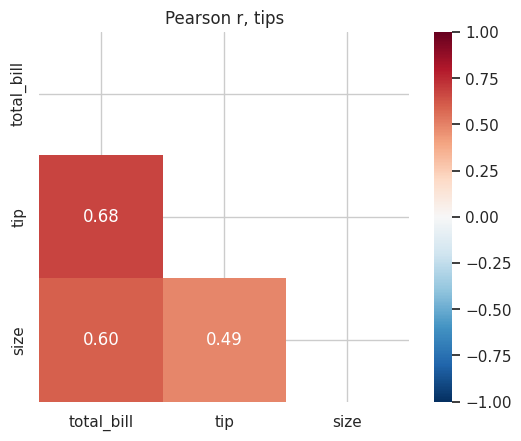

In [27]:
corr = num.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1, center=0, square=True)
plt.title("Pearson r, tips")

r for y = x² on symmetric x: -0.0
dataset
I      0.816
II     0.816
III    0.816
IV     0.817
dtype: float64


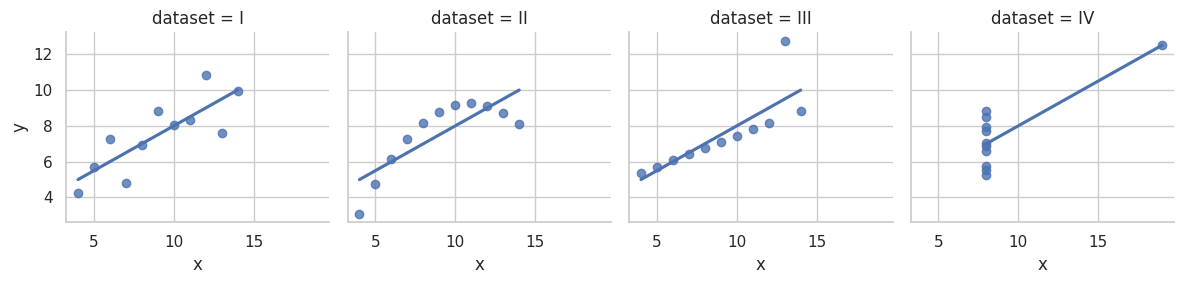

In [28]:
u = np.linspace(-3, 3, 200)
print("r for y = x² on symmetric x:", round(np.corrcoef(u, u**2)[0, 1], 3))

ans = sns.load_dataset("anscombe")
print(ans.groupby("dataset")[["x", "y"]].apply(lambda g: round(g.x.corr(g.y), 3)))
sns.lmplot(data=ans, x="x", y="y", col="dataset", col_wrap=4, ci=None, height=3)

## Case Study: Should we switch to Supplier B?
Let's work through the steps to evaluate Supplier A vs. Supplier B.

,count,mean,std,min,25%,50%,75%,max,95th_percentile
supplier,,,,,,,,,
A,60.0,10.311667,2.678482,6.3,8.075,10.3,12.425,16.2,14.35
B,60.0,9.116667,2.943604,5.4,7.475,8.1,10.225,19.8,15.90


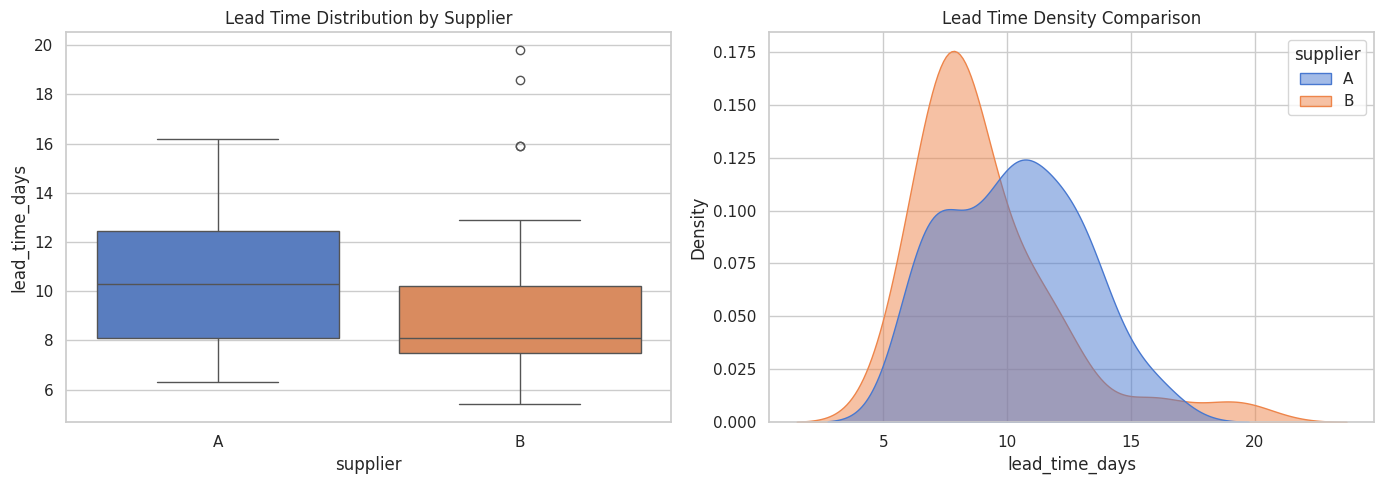

In [29]:
# 1. Explore — summaries (include the 95th percentile) and plots by supplier

# Group summaries
summary_by_supplier = orders.groupby('supplier')['lead_time_days'].describe()
summary_by_supplier['95th_percentile'] = orders.groupby('supplier')['lead_time_days'].quantile(0.95)
display(summary_by_supplier)

# Plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=orders, x='supplier', y='lead_time_days', ax=axes[0], palette='muted', hue='supplier', legend=False)
axes[0].set_title('Lead Time Distribution by Supplier')

sns.kdeplot(data=orders, x='lead_time_days', hue='supplier', fill=True, common_norm=False, alpha=0.5, ax=axes[1], palette='muted')
axes[1].set_title('Lead Time Density Comparison')
plt.tight_layout()
plt.show()

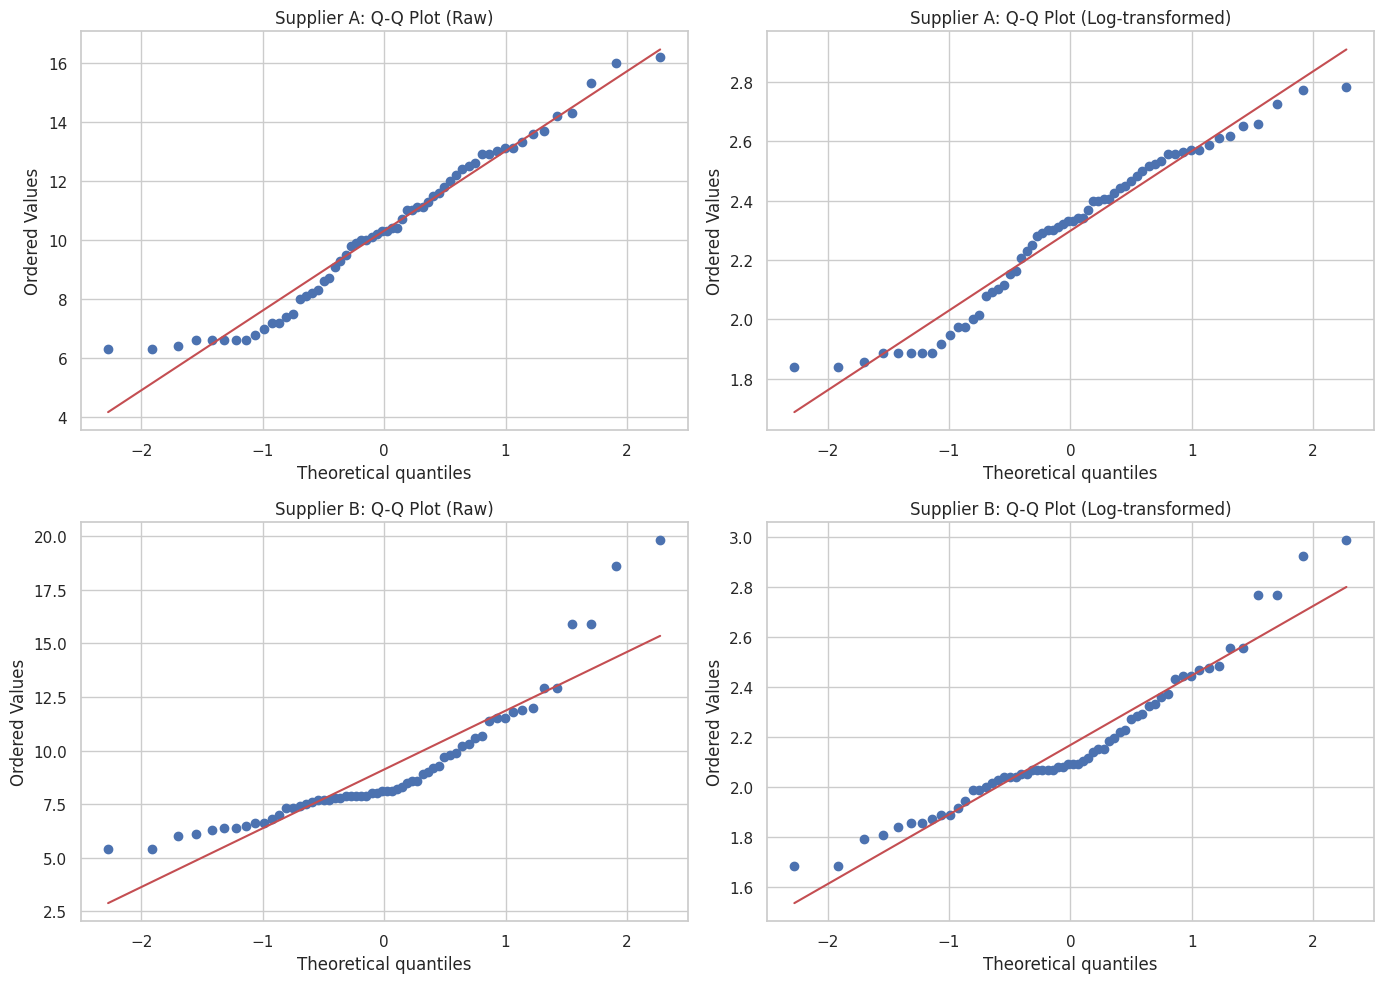

In [30]:
# 2. Check shape — Q-Q plots for both suppliers
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Supplier A
lead_a = orders[orders['supplier'] == 'A']['lead_time_days']
stats.probplot(lead_a, dist="norm", plot=axes[0, 0])
axes[0, 0].set_title("Supplier A: Q-Q Plot (Raw)")

stats.probplot(np.log(lead_a), dist="norm", plot=axes[0, 1])
axes[0, 1].set_title("Supplier A: Q-Q Plot (Log-transformed)")

# Supplier B
lead_b = orders[orders['supplier'] == 'B']['lead_time_days']
stats.probplot(lead_b, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title("Supplier B: Q-Q Plot (Raw)")

stats.probplot(np.log(lead_b), dist="norm", plot=axes[1, 1])
axes[1, 1].set_title("Supplier B: Q-Q Plot (Log-transformed)")

plt.tight_layout()
plt.show()

In [31]:
# 3. Estimate — bootstrap a 95% CI for the difference in medians (B − A)

bootstrap_diff_medians = []
num_boot_samples = 10000

for _ in range(num_boot_samples):
    boot_a = rng.choice(lead_a, size=len(lead_a), replace=True)
    boot_b = rng.choice(lead_b, size=len(lead_b), replace=True)
    bootstrap_diff_medians.append(np.median(boot_b) - np.median(boot_a))

ci_diff_medians = np.percentile(bootstrap_diff_medians, [2.5, 97.5])
obs_diff_medians = np.median(lead_b) - np.median(lead_a)

print(f"Observed difference in medians (B - A): {obs_diff_medians:.2f} days")
print(f"Bootstrap 95% CI for difference in medians: [{ci_diff_medians[0]:.2f}, {ci_diff_medians[1]:.2f}] days")

Observed difference in medians (B - A): -2.20 days
Bootstrap 95% CI for difference in medians: [-3.15, -1.15] days


In [32]:
# 4. Test — Welch's t-test on log lead time, Mann–Whitney U, and report Cohen's d

# Welch's t-test on log-transformed data
welch_t = stats.ttest_ind(np.log(lead_a), np.log(lead_b), equal_var=False)

# Mann-Whitney U test on raw data
mwu = stats.mannwhitneyu(lead_a, lead_b, alternative='two-sided')

# Cohen's d on raw data
mean_a, mean_b = np.mean(lead_a), np.mean(lead_b)
var_a, var_b = np.var(lead_a, ddof=1), np.var(lead_b, ddof=1)
n_a, n_b = len(lead_a), len(lead_b)
pooled_std = np.sqrt(((n_a - 1) * var_a + (n_b - 1) * var_b) / (n_a + n_b - 2))
cohens_d_val = (mean_b - mean_a) / pooled_std

print(f"Welch's t-test on Log Lead Time: t-stat={welch_t.statistic:.4f}, p-value={welch_t.pvalue:.4g}")
print(f"Mann-Whitney U test (raw data):  U-stat={mwu.statistic:.1f}, p-value={mwu.pvalue:.4g}")
print(f"Cohen's d (raw data):            {cohens_d_val:.3f}")

Welch's t-test on Log Lead Time: t-stat=2.6088, p-value=0.01026
Mann-Whitney U test (raw data):  U-stat=2339.0, p-value=0.004697
Cohen's d (raw data):            -0.425


### Your recommendation

**Recommendation:**  
Switching to Supplier B is highly recommended and fully justifies the 3.0% price premium. Our analysis demonstrates a statistically significant improvement in typical lead times, with Supplier B reducing the median delay by **2.20 days** (95% Bootstrap CI: [-3.15, -1.15] days). This meaningful speedup is confirmed by both Welch's t-test on log-transformed values ($p \approx 0.010$) and the non-parametric Mann-Whitney U test ($p \approx 0.005$), yielding a moderate standardized effect size (Cohen's $d = -0.425$). While Supplier B does present a heavier-tailed distribution with a higher 95th percentile delivery time (**15.90 days** compared to Supplier A's **14.35 days**), this tail risk can be easily managed by maintaining a minor safety-stock buffer. Ultimately, the consistent 2-day operational acceleration in standard lead times yields efficiencies that comfortably outweigh the marginal 3.0% increase in purchasing costs.

In [34]:
dists = {
    "Uniform(0,1)": stats.uniform(0, 1),
    "Normal(0,1)": stats.norm(0, 1),
    "Exponential(λ=1)": stats.expon(scale=1),
    "Lognormal(σ=0.5)": stats.lognorm(0.5),
    "Binomial(10, 0.5)": stats.binom(10, 0.5),
    "Poisson(3)": stats.poisson(3),
    "t(ν=5)": stats.t(5),
    "χ²(k=5)": stats.chi2(5),
}
pd.DataFrame({k: [float(v) for v in d.stats(moments="mvsk")] for k, d in dists.items()},
             index=["mean", "variance", "skew", "excess kurtosis"]).T.round(3)

,mean,variance,skew,excess kurtosis
"Uniform(0,1)",0.500,0.083,0.000,-1.200
"Normal(0,1)",0.000,1.000,0.000,0.000
Exponential(λ=1),1.000,1.000,2.000,6.000
Lognormal(σ=0.5),1.133,0.365,1.750,5.898
"Binomial(10, 0.5)",5.000,2.500,0.000,-0.200
Poisson(3),3.000,3.000,0.577,0.333
t(ν=5),0.000,1.667,0.000,6.000
χ²(k=5),5.000,10.000,1.265,2.400
